In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('Final_Marks_Data.csv')
df = pd.DataFrame(data)




In [3]:
df.loc[23]

Student_ID                       S1023
Attendance (%)                      91
Internal Test 1 (out of 40)         35
Internal Test 2 (out of 40)         32
Assignment Score (out of 10)         7
Daily Study Hours                    3
Final Exam Marks (out of 100)       67
Name: 23, dtype: object

In [4]:
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Student_ID                     2000 non-null   str  
 1   Attendance (%)                 2000 non-null   int64
 2   Internal Test 1 (out of 40)    2000 non-null   int64
 3   Internal Test 2 (out of 40)    2000 non-null   int64
 4   Assignment Score (out of 10)   2000 non-null   int64
 5   Daily Study Hours              2000 non-null   int64
 6   Final Exam Marks (out of 100)  2000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 119.3 KB


In [6]:
#finding Null Values count
df.isna().sum()

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64

In [7]:
# finding the duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
#feature engineering
# finding the most important features using filter method

df = df.drop('Student_ID', axis=1)

In [9]:
df.head()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,84,30,36,7,3,72
1,91,24,38,6,3,56
2,73,29,26,7,3,56
3,80,36,35,7,3,74
4,84,31,37,8,3,66


In [10]:
print(df.columns)

Index(['Attendance (%)', 'Internal Test 1 (out of 40)',
       'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)',
       'Daily Study Hours', 'Final Exam Marks (out of 100)'],
      dtype='str')


In [11]:
correlation = df.corr()['Final Exam Marks (out of 100)']
correlation

Attendance (%)                   0.725644
Internal Test 1 (out of 40)      0.689227
Internal Test 2 (out of 40)      0.691049
Assignment Score (out of 10)     0.669400
Daily Study Hours                0.412877
Final Exam Marks (out of 100)    1.000000
Name: Final Exam Marks (out of 100), dtype: float64

In [12]:
absoluate = correlation.abs()
sorted_values = absoluate.sort_values(ascending=False)
sorted_values

Final Exam Marks (out of 100)    1.000000
Attendance (%)                   0.725644
Internal Test 2 (out of 40)      0.691049
Internal Test 1 (out of 40)      0.689227
Assignment Score (out of 10)     0.669400
Daily Study Hours                0.412877
Name: Final Exam Marks (out of 100), dtype: float64

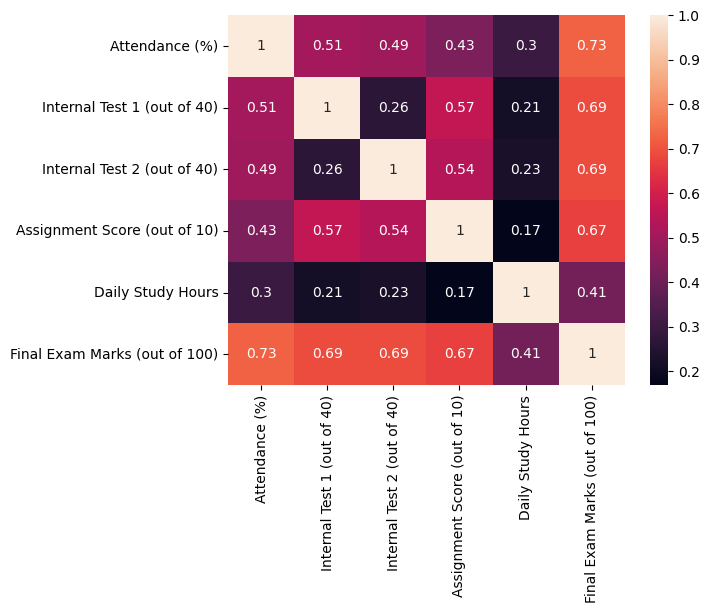

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True)
plt.show()



In [14]:
df.rename(columns = {'Internal Test 1 (out of 40)': 'Sessional_1', 'Internal Test 2 (out of 40)': 'Sessional_2', 'Assignment Score (out of 10)  ': 'Assignment_score','Final Exam Marks (out of 100)':'target'}, inplace = True)

In [15]:
print(df.columns)

Index(['Attendance (%)', 'Sessional_1', 'Sessional_2',
       'Assignment Score (out of 10)', 'Daily Study Hours', 'target'],
      dtype='str')


In [16]:
#Train and test Split
from sklearn.model_selection import train_test_split
x = df.drop('target', axis = 1)
y = df['target']


In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

len(y_train), len(y_test)

(1400, 600)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
prediction = model.predict(x_test)
prediction

array([64.28069146, 55.25497283, 65.43108123, 46.28996038, 41.56696541,
       76.52334193, 78.47692277, 60.08682916, 62.16756799, 68.80300875,
       62.56345944, 67.08077747, 75.80085315, 69.69144906, 43.02496457,
       73.67590082, 57.16434018, 76.87709445, 81.9414667 , 73.42225922,
       64.10680715, 62.85314728, 78.64397748, 48.25660843, 61.89606802,
       45.8644729 , 70.72523522, 80.01855774, 71.24524237, 61.26847399,
       64.88609276, 61.69951659, 53.14356211, 74.93956803, 67.08760706,
       61.20644773, 66.47120431, 50.41570373, 74.31682836, 74.72013258,
       56.72475525, 62.224003  , 75.62653058, 60.64108806, 49.69070213,
       85.50185038, 73.18415204, 58.567762  , 47.43863741, 82.81585516,
       60.87685371, 71.46957777, 71.52025904, 64.17448784, 64.97368352,
       49.35380411, 70.50552399, 71.54799741, 49.74366604, 43.23005834,
       79.14617186, 26.2102738 , 87.27983418, 65.3751838 , 51.26492981,
       71.74306627, 39.90858191, 64.07128092, 63.61505838, 58.03

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

print(mae)
print(mse)
print(r2)



3.6522797564482796
21.434086448509543
0.8234959385485636


In [21]:
Attendance = 100
Sessional_1 = 30
Sessional_2 = 29
Assignment_score =10
Dail_study_hours =6
user_data = [[Attendance, Sessional_1, Sessional_2, Assignment_score, Dail_study_hours]]
predicted_marks = model.predict(user_data)
print(predicted_marks)

[78.90777134]


c:\Users\jyothi.s\OneDrive\Documents\Machine Learning\Supervised\Linear_regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
import joblib

joblib.dump(model, "student_marks_model.pkl")

['student_marks_model.pkl']

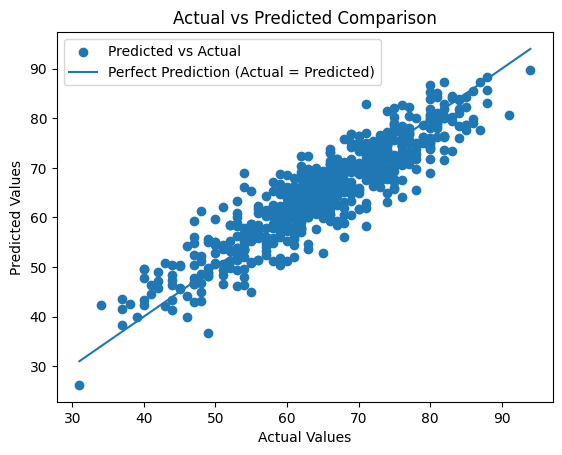

In [23]:
import matplotlib.pyplot as plt

# Scatter plot for Actual vs Predicted
plt.scatter(y_test, prediction, label="Predicted vs Actual")

# Perfect prediction reference line (Actual = Predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    label="Perfect Prediction (Actual = Predicted)"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Comparison")
plt.legend()

plt.show()

In [24]:
print(joblib.__version__)

1.5.3
